<div class="alert" style="background-color: #fff1f2; color: #9f1239; border-left: 6px solid #e11d48; border-top: 1px solid #fecdd3; border-right: 1px solid #fecdd3; border-bottom: 1px solid #fecdd3; border-radius: 8px; padding: 18px 22px; box-shadow: 0 4px 6px -1px rgba(225, 29, 72, 0.08); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;" id="my-bookmark">
    <div style="font-size: 12px; font-weight: 700; letter-spacing: 0.8px; text-transform: uppercase; color: #e11d48; margin-bottom: 6px;">
        GOAL:
    </div>
    <div style="font-size: 16px; font-weight: 600; line-height: 1.5;">
        Which neighborhoods are experiencing the highest environmental health burdens?
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

data = pd.read_pickle('all_clean_dfs.pkl')
globals().update(data)
all_dfs = data

In [2]:
#look at the data with less noise 
clean_df=clean_df.drop(columns=[ 
'Unique ID','Indicator ID','Message','Geo Join ID','Geo Type Name', 'Measure', 'Measure Info']) 
        #Remaining columns: 
        ##'Name', 'Geo Place Name', 'Time Period', 'Data Value', 'Start_Date'
clean_df.head(5) 

,Name,Geo Place Name,Time Period,Data Value,start_date,end_date
0,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Summer 2009,20.38,2009-06-01,2009-08-31
1,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Annual Average 2013,19.48,2012-12-01,NaT
2,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Winter 2010-11,29.44,2010-12-01,2011-02-28
3,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Summer 2010,18.08,2010-06-01,2010-08-31
4,Nitrogen dioxide (NO2),Bay Ridge and Dyker Heights (CD10),Summer 2011,18.06,2011-06-01,2011-08-31


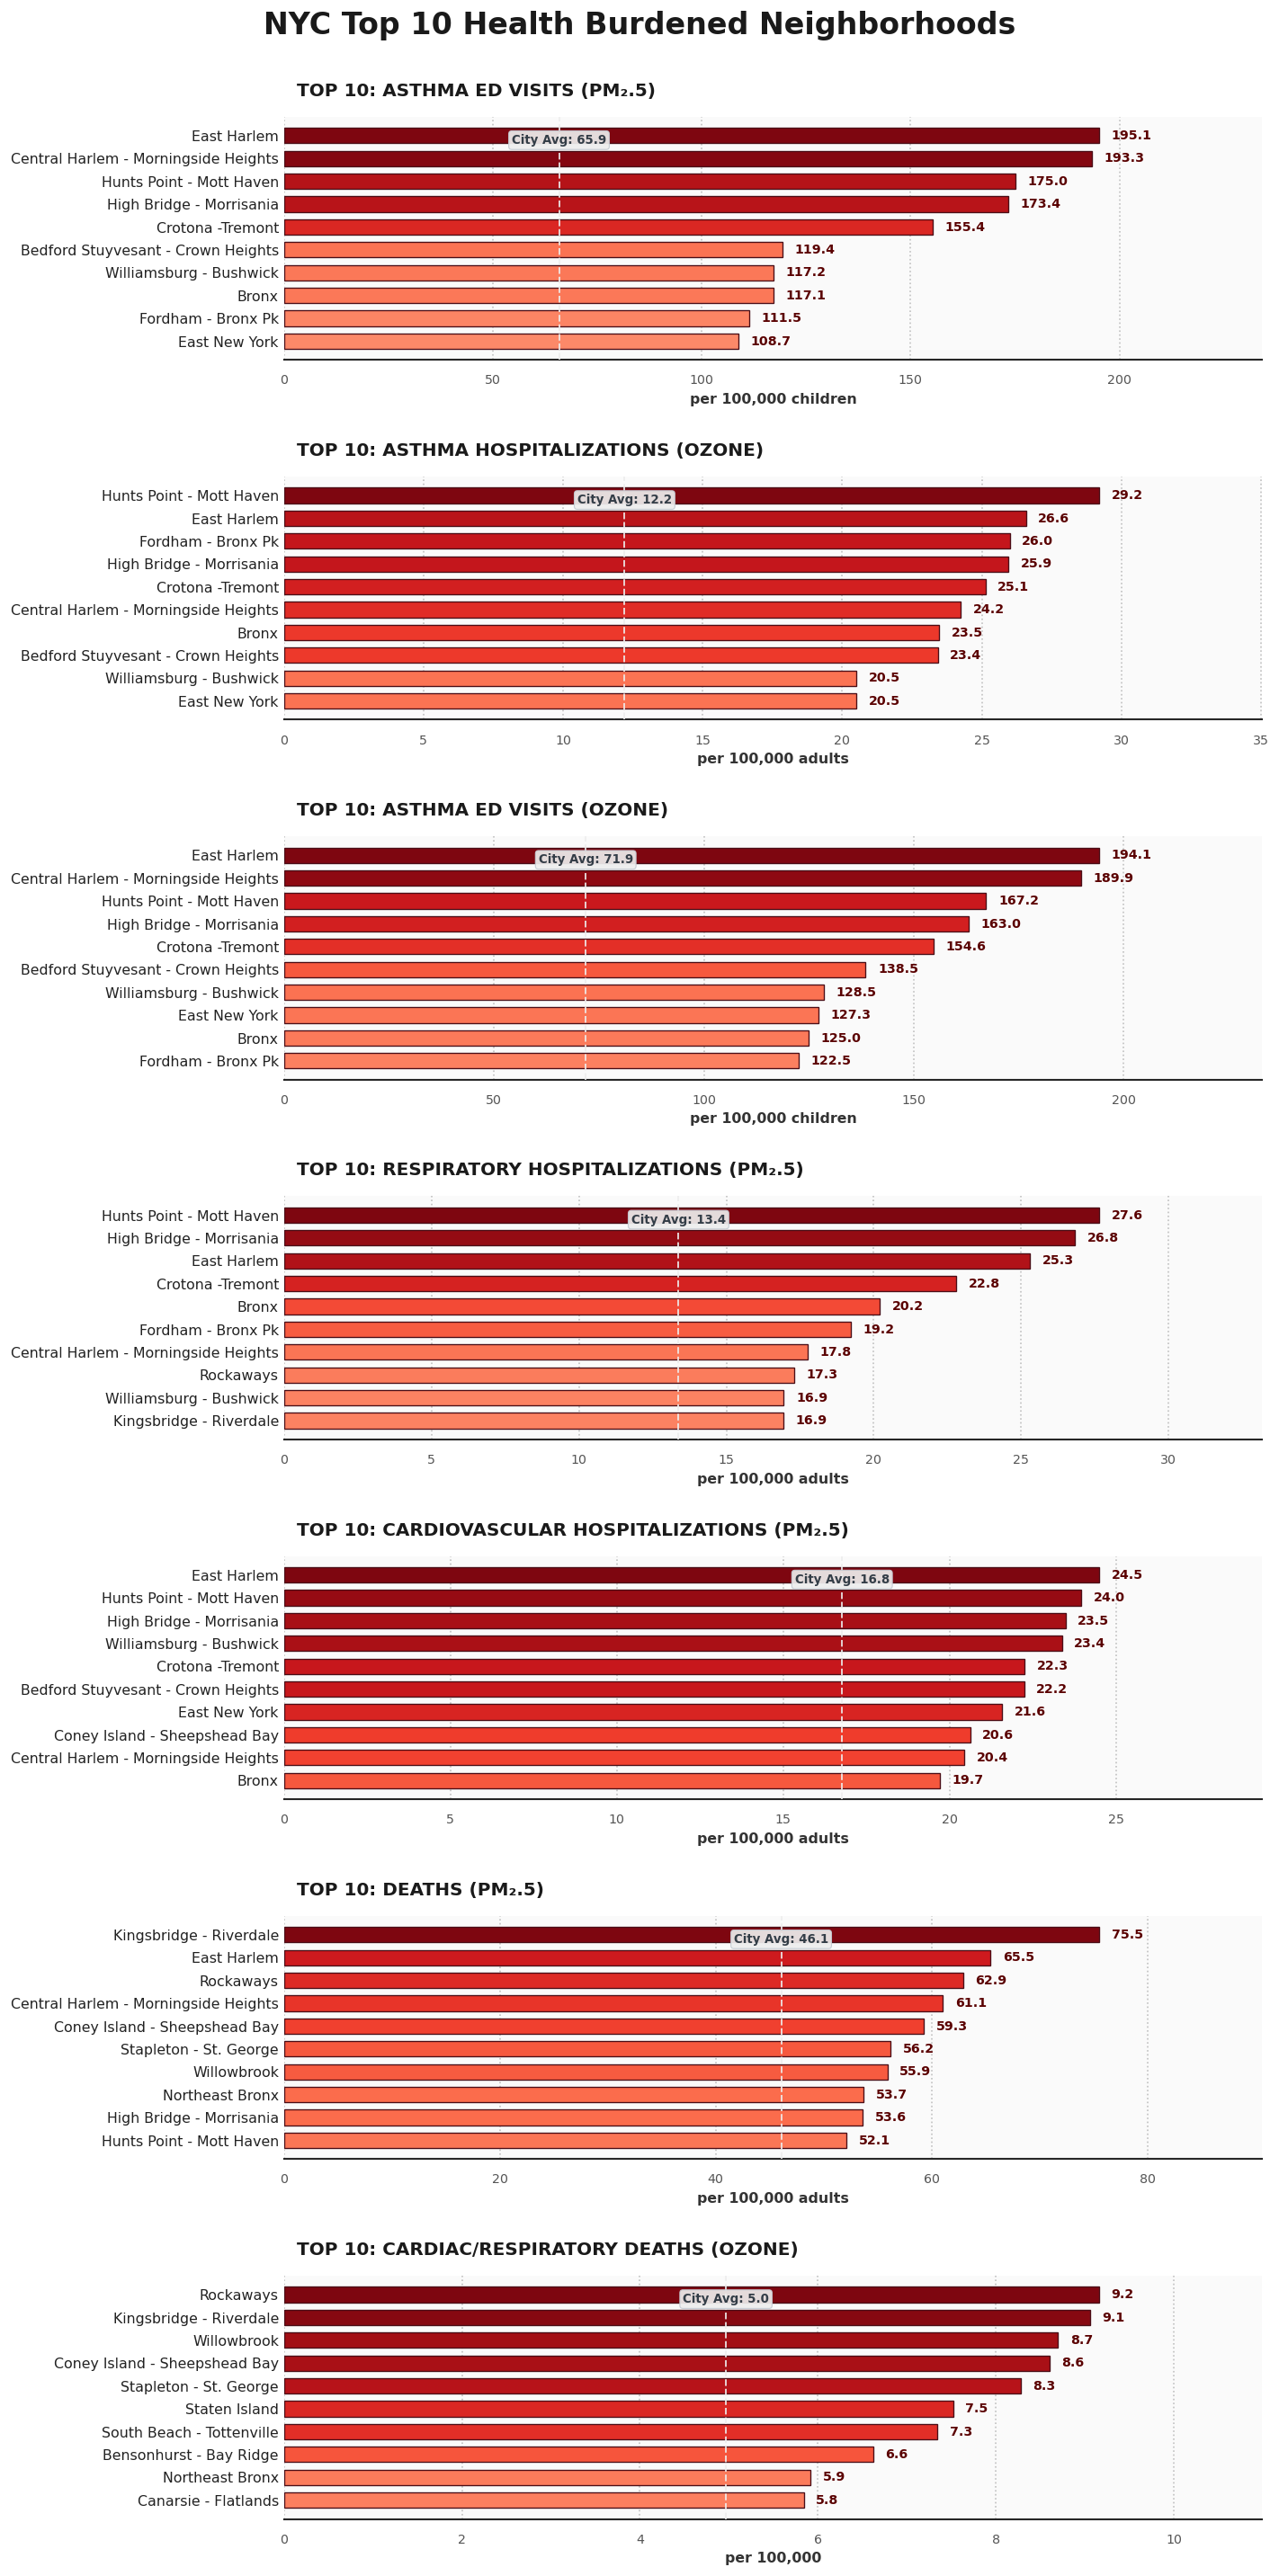

In [3]:
sns.set_theme(style="white", font_scale=0.95)

# Define labels
health_labels = {
    "asth_pm_df": "Asthma ED Visits (PM₂.5)",
    "asth_oz_h_df": "Asthma Hospitalizations (Ozone)",
    "asth_oz_ed_df": "Asthma ED Visits (Ozone)",
    "resp_df": "Respiratory Hospitalizations (PM₂.5)",
    "cardio_df": "Cardiovascular Hospitalizations (PM₂.5)",
    "deaths_pm_df": "Deaths (PM₂.5)",
    "deaths_oz_df": "Cardiac/Respiratory Deaths (Ozone)",
}

# Filter to active variables
target_dfs = {
    label: all_dfs[key]
    for key, label in health_labels.items()
    if key in all_dfs and not all_dfs[key].empty
}

# Grid setup
num_metrics = len(target_dfs)
num_rows = num_metrics if num_metrics > 0 else 1

fig, axes = plt.subplots(num_rows, 1, figsize=(12, 3.4 * num_rows), dpi=120)

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
axes = axes.flatten()

# Loop through variables
for i, (metric_name, df) in enumerate(target_dfs.items()):
    if i >= len(axes):
        break

    ax = axes[i]

    # Detect metric value column
    val_col = next(
        (
            col
            for col in [
                "Data Value",
                "Value",
                "Estimated Annual Rate per 100,000",
            ]
            if col in df.columns
        ),
        None,
    )

    if val_col is None or "Geo Place Name" not in df.columns:
        ax.text(
            0.5,
            0.5,
            "Missing Column Data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(metric_name, fontsize=11, fontweight="bold")
        continue

    # Extract unit label
    unit_label = ""
    for unit_col in ["Measure Info", "Measure", "Unit", "Measure_Info"]:
        if unit_col in df.columns and not df[unit_col].dropna().empty:
            unit_label = str(df[unit_col].dropna().iloc[0]).strip()
            break

    # Group neighborhood records
    df_clean = (
        df.dropna(subset=[val_col, "Geo Place Name"])
        .groupby("Geo Place Name", as_index=False)[val_col]
        .mean()
    )

    if df_clean.empty:
        continue

    # Compute citywide average
    city_avg = df_clean[val_col].mean()

    # Get Top 10 sorted ascending for horizontal layout
    top_10 = df_clean.nlargest(10, val_col).sort_values(
        by=val_col, ascending=True
    )

    # Red Colormap Gradient
    values = top_10[val_col].values
    norm = mcolors.Normalize(vmin=values.min() * 0.85, vmax=values.max())
    colormap = plt.get_cmap("Reds")
    bar_colors = [colormap(0.30 + 0.65 * norm(v)) for v in values]

    # Plot horizontal bars
    bars = ax.barh(
        top_10["Geo Place Name"],
        top_10[val_col],
        color=bar_colors,
        edgecolor="#4A0E17",
        linewidth=0.8,
        height=0.68,
        zorder=3,
    )

    # Styling & Gridlines
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)
    sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

    # Subplot Header
    ax.set_title(
        f"  TOP 10: {metric_name.upper()}  ",
        fontsize=12,
        fontweight="bold",
        pad=14,
        loc="left",
        color="#1A1A1A",
    )

    # X-axis label
    x_label_text = unit_label if unit_label else "Data Value"
    ax.set_xlabel(
        x_label_text, fontsize=9.5, fontweight="bold", color="#333333"
    )

    ax.tick_params(axis="y", labelsize=9.5, colors="#222222", length=0)
    ax.tick_params(axis="x", labelsize=8.5, colors="#555555")

    # Numeric End Badges on Bars
    max_val = top_10[val_col].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + (max_val * 0.015),
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.1f}",
            ha="left",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color="#5A0000",
        )

    #City average line
    ax.axvline(
        x=city_avg,
        color="#eeeeee",
        linestyle="--",
        linewidth=1.2,
        alpha=0.85,
        zorder=5,
    )

    #City average box
    ax.text(
        city_avg,
        8.8,
        f"City Avg: {city_avg:,.1f}",
        color="#333D47",
        fontsize=8,
        fontweight="bold",
        va="center",
        ha="center",
        zorder=7,
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#eeeeee",
            edgecolor="#C5CBD3",
            linewidth=0.7,
            alpha=0.92,
        ),
    )

    # Scale X limit to accommodate bars and labels
    ax.set_xlim(0, max(max_val, city_avg) * 1.20)

# Remove unused subplots
for j in range(len(target_dfs), len(axes)):
    fig.delaxes(axes[j])

# Title Banner
plt.suptitle(
    "NYC Top 10 Health Burdened Neighborhoods",
    fontsize=20,
    fontweight="bold",
    color="#1A1A1A",
    y=1.002,
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.48)
plt.show()

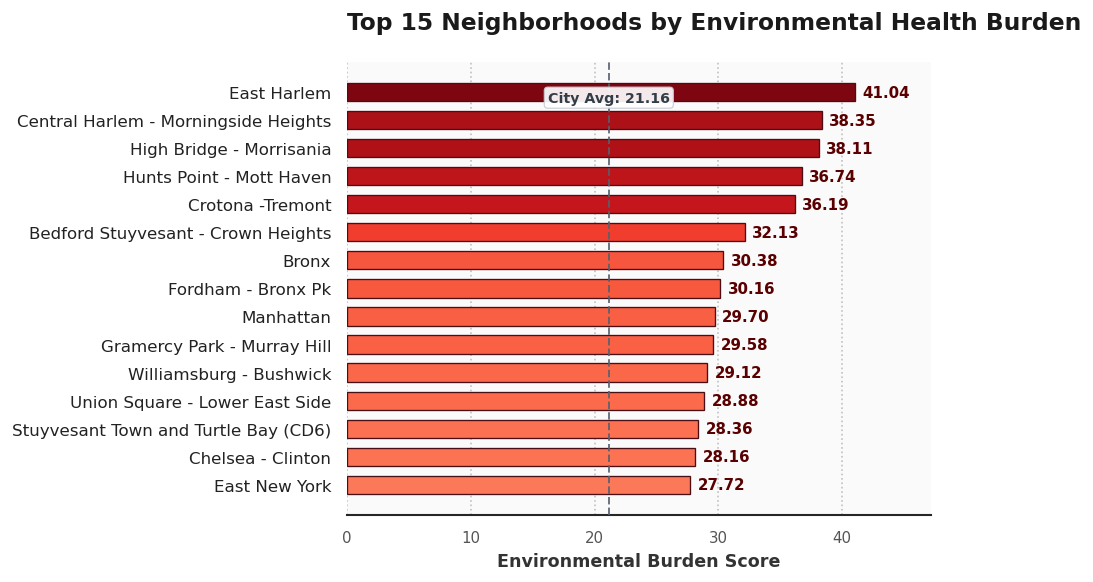

In [4]:
sns.set_theme(style="white", font_scale=0.95)

# Use 'all_dfs'
valid_dfs = [v for v in all_dfs.values() if isinstance(v, pd.DataFrame)]

if valid_dfs:
    master_df = pd.concat(valid_dfs, ignore_index=True)

    # Detect metric value column
    val_col = next(
        (
            col
            for col in [
                "Data Value",
                "Value",
                "Estimated Annual Rate per 100,000",
                "Mean",
            ]
            if col in master_df.columns
        ),
        None,
    )

    if not val_col or "Geo Place Name" not in master_df.columns:
        raise KeyError(
            "Could not find required columns ('Geo Place Name' and value columns)."
        )


    if "composite_health_burden" not in master_df.columns:
        neighborhood_summary = (
            master_df.groupby("Geo Place Name")[val_col]
            .mean()
            .reset_index()
        )
        neighborhood_summary.columns = [
            "neighborhood",
            "environmental_burden_score",
        ]
    else:
        neighborhood_summary = (
            master_df[["Geo Place Name", "composite_health_burden"]]
            .drop_duplicates(subset=["Geo Place Name"])
            .copy()
        )
        neighborhood_summary = neighborhood_summary.rename(
            columns={
                "Geo Place Name": "neighborhood",
                "composite_health_burden": "environmental_burden_score",
            }
        )
else:
    raise ValueError("No valid pandas DataFrames found in `all_dfs`!")

# Compute Citywide Average
city_avg = neighborhood_summary["environmental_burden_score"].mean()

# Extract Top 15 sorted ascending
top_15 = neighborhood_summary.nlargest(
    15, "environmental_burden_score"
).sort_values(by="environmental_burden_score", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# Red Colormap Gradient
scores = top_15["environmental_burden_score"].values
norm = mcolors.Normalize(vmin=scores.min() * 0.85, vmax=scores.max())
colormap = plt.get_cmap("Reds")
bar_colors = [colormap(0.30 + 0.65 * norm(s)) for s in scores]

# Plot Horizontal Bars
bars = ax.barh(
    top_15["neighborhood"],
    top_15["environmental_burden_score"],
    color=bar_colors,
    edgecolor="#4A0E17",
    linewidth=0.8,
    height=0.65,
    zorder=3,
)

# Background & gridlines
ax.set_facecolor("#FAFAFA")
ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)
sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

# Title & styling
ax.set_title(
    "Top 15 Neighborhoods by Environmental Health Burden",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="left",
    color="#1A1A1A",
)

ax.set_xlabel(
    "Environmental Burden Score",
    fontsize=10.5,
    fontweight="bold",
    color="#333333",
)
ax.tick_params(axis="y", labelsize=10, colors="#222222")
ax.tick_params(axis="x", labelsize=9, colors="#555555")

# Value Badges at end of bars
max_val = top_15["environmental_burden_score"].max()
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.2f}",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#5A0000",
    )

# appearance
ax.axvline(
    x=city_avg,
    color="#55606E",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    zorder=5,
)

#appearance
ax.text(
    city_avg,
    13.8,
    f"City Avg: {city_avg:,.2f}",
    color="#333D47",
    fontsize=8.5,
    fontweight="bold",
    va="center",
    ha="center",
    zorder=7,
    clip_on=False,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="#FFFFFF",
        edgecolor="#C5CBD3",
        linewidth=0.7,
        alpha=0.92,
    ),
)

ax.set_xlim(0, max(max_val, city_avg) * 1.15)
plt.tight_layout()
plt.show()

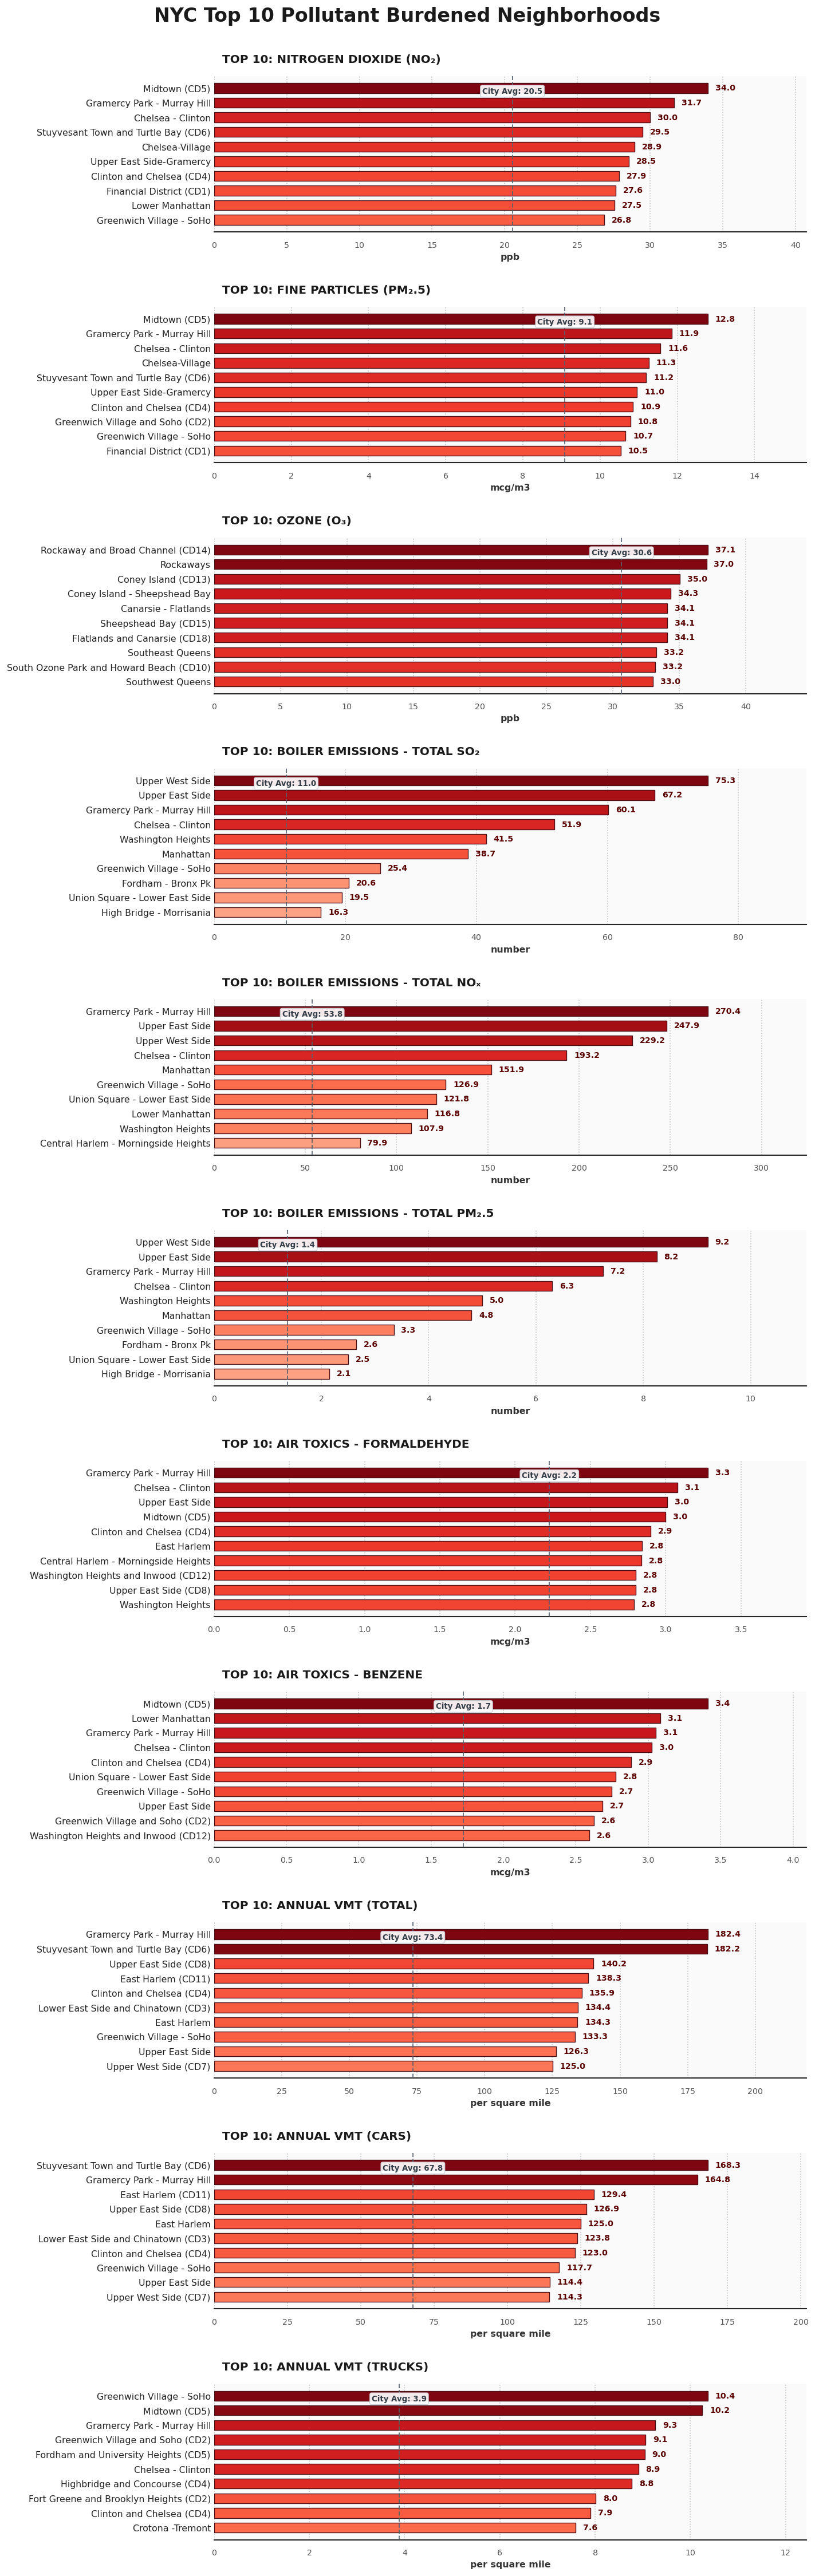

In [5]:
sns.set_theme(style="white", font_scale=0.95)

# Define pollutant labels and keys mapping
pollu_labels = {
    "no2_df": "Nitrogen Dioxide (NO₂)",
    "pm25_df": "Fine Particles (PM₂.5)",
    "ozone_df": "Ozone (O₃)",
    "so2_em_df": "Boiler Emissions - Total SO₂",
    "nox_em_df": "Boiler Emissions - Total NOₓ",
    "pm25_em_df": "Boiler Emissions - Total PM₂.5",
    "form_df": "Air Toxics - Formaldehyde",
    "benz_df": "Air Toxics - Benzene",
    "vmt_df": "Annual VMT (Total)",
    "vmt_cars_df": "Annual VMT (Cars)",
    "vmt_trck_df": "Annual VMT (Trucks)",
}

# Filter to active variables using pollu_labels
target_dfs = {
    label: all_dfs[key]
    for key, label in pollu_labels.items()
    if key in all_dfs and isinstance(all_dfs[key], pd.DataFrame) and not all_dfs[key].empty
}

# Grid setup
num_metrics = len(target_dfs)
num_rows = num_metrics if num_metrics > 0 else 1

fig, axes = plt.subplots(num_rows, 1, figsize=(12, 3.4 * num_rows), dpi=120)

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
axes = axes.flatten()

# Loop through variables
for i, (metric_name, df) in enumerate(target_dfs.items()):
    if i >= len(axes):
        break

    ax = axes[i]

    # Detect metric value column
    val_col = next(
        (
            col
            for col in [
                "Data Value",
                "Value",
                "Estimated Annual Rate per 100,000",
                "Mean",
                "Amount",
            ]
            if col in df.columns
        ),
        None,
    )

    if val_col is None or "Geo Place Name" not in df.columns:
        ax.text(
            0.5,
            0.5,
            "Missing Column Data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(metric_name, fontsize=11, fontweight="bold")
        continue

    # Extract unit label
    unit_label = ""
    for unit_col in ["Measure Info", "Measure", "Unit", "Measure_Info"]:
        if unit_col in df.columns and not df[unit_col].dropna().empty:
            unit_label = str(df[unit_col].dropna().iloc[0]).strip()
            break

    # Group neighborhood records
    df_clean = (
        df.dropna(subset=[val_col, "Geo Place Name"])
        .groupby("Geo Place Name", as_index=False)[val_col]
        .mean()
    )

    if df_clean.empty:
        continue

    # Compute citywide average
    city_avg = df_clean[val_col].mean()

    # Get Top 10 sorted ascending for horizontal layout
    top_10 = df_clean.nlargest(10, val_col).sort_values(
        by=val_col, ascending=True
    )

    # Red Colormap Gradient
    values = top_10[val_col].values
    norm = mcolors.Normalize(vmin=values.min() * 0.85, vmax=values.max())
    colormap = plt.get_cmap("Reds")
    bar_colors = [colormap(0.30 + 0.65 * norm(v)) for v in values]

    # Plot horizontal bars
    bars = ax.barh(
        top_10["Geo Place Name"],
        top_10[val_col],
        color=bar_colors,
        edgecolor="#4A0E17",
        linewidth=0.8,
        height=0.68,
        zorder=3,
    )

    # Styling & Gridlines
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)
    sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

    # Subplot Header
    ax.set_title(
        f"  TOP 10: {metric_name.upper()}  ",
        fontsize=12,
        fontweight="bold",
        pad=14,
        loc="left",
        color="#1A1A1A",
    )

    # X-axis label
    x_label_text = unit_label if unit_label else "Data Value"
    ax.set_xlabel(
        x_label_text, fontsize=9.5, fontweight="bold", color="#333333"
    )

    ax.tick_params(axis="y", labelsize=9.5, colors="#222222", length=0)
    ax.tick_params(axis="x", labelsize=8.5, colors="#555555")

    # Numeric End Badges on Bars
    max_val = top_10[val_col].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + (max_val * 0.015),
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.1f}",
            ha="left",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color="#5A0000",
        )

    # City average line
    ax.axvline(
        x=city_avg,
        color="#55606E",
        linestyle="--",
        linewidth=1.2,
        alpha=0.85,
        zorder=5,
    )

    # City average box
    ax.text(
        city_avg,
        8.8,
        f"City Avg: {city_avg:,.1f}",
        color="#333D47",
        fontsize=8,
        fontweight="bold",
        va="center",
        ha="center",
        zorder=7,
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#FFFFFF",
            edgecolor="#C5CBD3",
            linewidth=0.7,
            alpha=0.92,
        ),
    )

    # Scale X limit to accommodate bars and labels
    ax.set_xlim(0, max(max_val, city_avg) * 1.20)

# Remove unused subplots
for j in range(len(target_dfs), len(axes)):
    fig.delaxes(axes[j])

# Title Banner
plt.suptitle(
    "NYC Top 10 Pollutant Burdened Neighborhoods",
    fontsize=20,
    fontweight="bold",
    color="#1A1A1A",
    y=1.002,
)

plt.tight_layout()
plt.subplots_adjust(hspace=0.48)
plt.show()

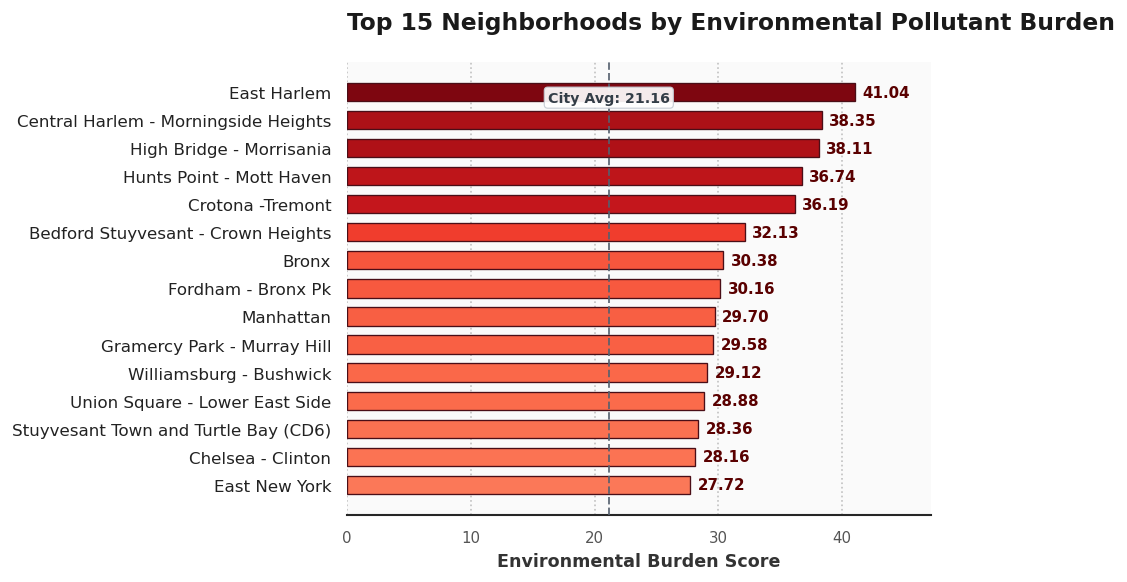

In [6]:
# Ensure summary DataFrame exists
import pandas as pd

#Combine dfs
valid_dfs = [v for v in all_dfs.values() if isinstance(v, pd.DataFrame)]
master_df = pd.concat(valid_dfs, ignore_index=True)

# Check if composite_health_burden exists; if not, compute it from value columns
if "composite_health_burden" not in master_df.columns:
    val_col = next(
        (col for col in ["Data Value", "Value", "Mean"] if col in master_df.columns),
        None,
    )
    master_df["composite_health_burden"] = master_df.groupby("Geo Place Name")[
        val_col
    ].transform("mean")

# Build  neighborhood summary 
neighborhood_summary = (
    master_df[["Geo Place Name", "composite_health_burden"]]
    .drop_duplicates(subset=["Geo Place Name"])
    .copy()
)

neighborhood_summary = neighborhood_summary.rename(
    columns={
        "Geo Place Name": "neighborhood",
        "composite_health_burden": "environmental_burden_score",
    }
)

sns.set_theme(style="white", font_scale=0.95)

# Compute Citywide Average Baseline
city_avg = neighborhood_summary["environmental_burden_score"].mean()

# Extract Top 15 
top_15 = neighborhood_summary.nlargest(
    15, "environmental_burden_score"
).sort_values(by="environmental_burden_score", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# Red Colormap Gradient
scores = top_15["environmental_burden_score"].values

# Gradient bars
norm = mcolors.Normalize(vmin=scores.min() * 0.85, vmax=scores.max())
colormap = plt.get_cmap("Reds")
bar_colors = [colormap(0.30 + 0.65 * norm(s)) for s in scores]

# Plot Horizontal Bars
bars = ax.barh(
    top_15["neighborhood"],
    top_15["environmental_burden_score"],
    color=bar_colors,
    edgecolor="#4A0E17",  # Dark crimson border around each bar
    linewidth=0.8,
    height=0.65,
    zorder=3,
)

# Background & gridlines
ax.set_facecolor("#FAFAFA")
ax.grid(True, linestyle=":", alpha=0.5, color="#888888", axis="x", zorder=0)

sns.despine(top=True, right=True, left=True, bottom=False, ax=ax)

# Title & styling
ax.set_title(
    "Top 15 Neighborhoods by Environmental Pollutant Burden",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="left",
    color="#1A1A1A",
)

ax.set_xlabel(
    "Environmental Burden Score",
    fontsize=10.5,
    fontweight="bold",
    color="#333333",
)
ax.tick_params(axis="y", labelsize=10, colors="#222222")
ax.tick_params(axis="x", labelsize=9, colors="#555555")

# Value Badges at end of bars
max_val = top_15["environmental_burden_score"].max()
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.2f}",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#5A0000",
    )

# City Average Line
ax.axvline(
    x=city_avg,
    color="#55606E",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    zorder=5,
)

# badge & text
ax.text(
    city_avg,
    13.8,  # Sits right above the top bar (index 14)
    f"City Avg: {city_avg:,.2f}",
    color="#333D47",
    fontsize=8.5,
    fontweight="bold",
    va="center",
    ha="center",
    zorder=7,
    clip_on=False,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="#FFFFFF",
        edgecolor="#C5CBD3",
        linewidth=0.7,
        alpha=0.92,
    ),
)

# Adjust X-axis limit to accommodate bars, badges, and line
ax.set_xlim(0, max(max_val, city_avg) * 1.15)

plt.tight_layout()
plt.show()